In [1]:
from dataclasses import dataclass
from datetime import datetime
from typing import Literal

@dataclass
class MetricsValue:
    value: float                                # Valor de la métrica
    value_name: str                             # Nombre de la métrica (Ej: Loss (MSE))

@dataclass
class MetricsDto:
    name: str                                   # Nombre del entrenamiento, simplemente informativo
    timestamp: datetime                         # Momento del envío para trazabilidad con métricas de consumo
    step: int                                   # Número del paso actual
    step_type: str                              # Tipo de paso: epoch / bach / iteración
    phase: Literal["train", "val", "test"]
    values: list[MetricsValue]  

In [4]:
import os
import csv
import json
import xgboost as xgb
import paho.mqtt.client as mqtt
from datetime import datetime
from dataclasses import asdict
from sklearn.metrics import r2_score
import pandas as pd
import numpy as np
import xgboost as xgb
import paho.mqtt.client as mqtt
import json
from dataclasses import asdict
from datetime import datetime

from sklearn.metrics import mean_squared_error, r2_score

# Aseguramos la carpeta de logs como hace tu amigo
folder = "AccuracyFiles"
os.makedirs(folder, exist_ok=True)
filename = os.path.join(folder, f"Accuracy_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv")

class XGBoostMetricsCallback(xgb.callback.TrainingCallback):
    def __init__(self, train_name, dtest, y_test):
        super().__init__()
        self.name = train_name
        self.dtest = dtest
        self.y_test = y_test
        
        # Configuración del cliente MQTT interna como tu amigo
        try:
            self.mqtt_client = mqtt.Client()
            # Cambia "localhost" por tu IP de Ubuntu si es necesario
            self.mqtt_client.connect("169.254.51.0", 1883, 60)
            self.mqtt_client.loop_start()
            print("✅ Broker conectado desde el Callback")
        except Exception as e:
            print(f"❌ Error conectando con el broker: {e}")
            self.mqtt_client = None

    def after_iteration(self, model, epoch, evals_log=None):
        now = datetime.now().isoformat()
        train_rmse = float(evals_log['train']['rmse'][-1])
        val_rmse = float(evals_log['test']['rmse'][-1])
        preds = model.predict(self.dtest)
        r2_val = float(r2_score(self.y_test, preds))

        # --- 2. CREACIÓN DE DTOS (ESTILO AMIGO) ---
        train_dto = MetricsDto(
            name=self.name,
            timestamp=now,
            step=epoch,
            step_type="epoch",
            phase="train",
            values=[
                MetricsValue(value=train_rmse, value_name="RMSE"),
                MetricsValue(value=max(0, r2_val), value_name="Accuracy")
            ]
        )

        val_dto = MetricsDto(
            name=self.name,
            timestamp=now,
            step=epoch ,
            step_type="epoch",
            phase="val",
            values=[
                MetricsValue(value=val_rmse, value_name="RMSE"),
                MetricsValue(value=max(0, r2_val), value_name="Accuracy")
            ]
        )

        # --- 3. ENVÍO MQTT ---
        if self.mqtt_client:
            self.mqtt_client.publish("training/metrics", json.dumps(asdict(train_dto)), qos=1)
            self.mqtt_client.publish("training/metrics", json.dumps(asdict(val_dto)), qos=1)

        # --- 4. GUARDADO EN CSV (ESTILO AMIGO) ---
        self.save_data({"epoch": epoch , "rmse": val_rmse, "accuracy": r2_val})

        if epoch % 10 == 0:
            print(f"🚀 {self.name} - Iteración {epoch}: RMSE={val_rmse:.2f}")

        return False

    def save_data(self, data):
        # Escribimos en el CSV localmente para tener backup
        file_exists = os.path.isfile(filename)
        with open(filename, "a", newline="") as file:
            writer = csv.writer(file)
            if not file_exists:
                writer.writerow(["timestamp", "epoch", "rmse", "accuracy"])
            writer.writerow([datetime.now().isoformat(), data["epoch"], data["rmse"], data["accuracy"]])

In [5]:
import numpy as np
import pandas as pd
import xgboost as xgb
import kagglehub
import os
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ==========================================
# 1. CARGA DESDE KAGGLE
# ==========================================
print("⏳ Descargando dataset...")
path = kagglehub.dataset_download("mohankrishnathalla/sleep-health-and-daily-performance-dataset")
csv_file = os.path.join(path, "sleep_health_dataset.csv")
df = pd.read_csv(csv_file)

target_col = 'cognitive_performance_score'
X = df.drop(columns=[target_col])
y = df[target_col].values

# ==========================================
# 2. PIPELINE DE PREPROCESAMIENTO (LA CLAVE)
# ==========================================
# Separamos columnas por tipo
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns

# Definimos las transformaciones
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_features)
    ])

print("🛠️ Aplicando Pipeline de preprocesamiento...")
X_processed = preprocessor.fit_transform(X)
X_processed = np.asarray(X_processed).astype(np.float32) # Convertimos a float puro para XGBoost

# Dividimos los datos ya numéricos
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

# ==========================================
# 3. CONFIGURACIÓN Y ENTRENAMIENTO
# ==========================================
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Asegúrate de que XGBoostMetricsCallback esté definido arriba en tu script
my_callback = XGBoostMetricsCallback(train_name="Sleep Performance Session", dtest=dtest, y_test=y_test)

params = {
    "objective": "reg:squarederror",
    "tree_method": "exact",   # Fuerza bruta de CPU
    "max_depth": 15,          # Profundidad alta
    "eta": 0.01,              # Bajamos el aprendizaje para que dure más la demo
    "eval_metric": "rmse",
}


model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=300,
    evals=[(dtrain, 'train'), (dtest, 'test')],
    callbacks=[my_callback],
    verbose_eval=50
)
columnas_finales = preprocessor.get_feature_names_out()

print(f"🔍 XGBoost está entrenando con {len(columnas_finales)} columnas:")
print(columnas_finales)


⏳ Descargando dataset...
🛠️ Aplicando Pipeline de preprocesamiento...


/tmp/ipykernel_10316/1881541352.py:33: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  self.mqtt_client = mqtt.Client()


✅ Broker conectado desde el Callback
🚀 Sleep Performance Session - Iteración 0: RMSE=21.97
[0]	train-rmse:22.06464	test-rmse:21.97239
🚀 Sleep Performance Session - Iteración 10: RMSE=20.13
🚀 Sleep Performance Session - Iteración 20: RMSE=18.48
🚀 Sleep Performance Session - Iteración 30: RMSE=17.01
🚀 Sleep Performance Session - Iteración 40: RMSE=15.69
🚀 Sleep Performance Session - Iteración 50: RMSE=14.51
[50]	train-rmse:14.03317	test-rmse:14.51222
🚀 Sleep Performance Session - Iteración 60: RMSE=13.47
🚀 Sleep Performance Session - Iteración 70: RMSE=12.54
🚀 Sleep Performance Session - Iteración 80: RMSE=11.73
🚀 Sleep Performance Session - Iteración 90: RMSE=11.01
🚀 Sleep Performance Session - Iteración 100: RMSE=10.37
[100]	train-rmse:9.13798	test-rmse:10.37442
🚀 Sleep Performance Session - Iteración 110: RMSE=9.82
🚀 Sleep Performance Session - Iteración 120: RMSE=9.33
🚀 Sleep Performance Session - Iteración 130: RMSE=8.91
🚀 Sleep Performance Session - Iteración 140: RMSE=8.54
🚀 Sleep

In [6]:
import os
import pandas as pd
import numpy as np
import xgboost as xgb
import kagglehub
import paho.mqtt.client as mqtt
import json
import csv
from datetime import datetime
from dataclasses import dataclass, asdict
from typing import Literal
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ==========================================
# 1. CONFIGURACIÓN MQTT Y DTOS
# ==========================================
@dataclass
class MetricsValue:
    value: float
    value_name: str

@dataclass
class MetricsDto:
    name: str
    timestamp: str
    step: int
    step_type: str
    phase: Literal["train", "val", "test"]
    values: list[MetricsValue]

class StudentPerformanceCallback(xgb.callback.TrainingCallback):
    def __init__(self, train_name, broker_ip="169.254.51.0"):
        super().__init__()
        self.name = train_name
        self.mqtt_client = mqtt.Client()
        try:
            self.mqtt_client.connect(broker_ip, 1883, 60)
            self.mqtt_client.loop_start()
        except: self.mqtt_client = None

    def after_iteration(self, model, epoch, evals_log):
        if not evals_log: return False
        now = datetime.now().isoformat()
        tr_rmse = float(evals_log['train']['rmse'][-1])
        te_rmse = float(evals_log['test']['rmse'][-1])

        if self.mqtt_client:
            p_tr = MetricsDto(self.name, now, epoch, "epoch", "train", [MetricsValue(tr_rmse, "RMSE")])
            p_te = MetricsDto(self.name, now, epoch, "epoch", "val", [MetricsValue(te_rmse, "RMSE")])
            self.mqtt_client.publish("training/metrics", json.dumps(asdict(p_tr)), qos=1)
            self.mqtt_client.publish("training/metrics", json.dumps(asdict(p_te)), qos=1)
        
        if epoch % 10 == 0:
            print(f"🎓 Iter {epoch} | RMSE Val: {te_rmse:.4f}")
        return False

# ==========================================
# 2. DESCARGA Y CARGA DEL DATASET (500K)
# ==========================================
print("⏳ Descargando 500k Student Dataset...")
path = kagglehub.dataset_download("waddahali/500k-student-performance-and-behavior-dataset")
print("Path to dataset files:", path)
csv_file = os.path.join(path, "Student Performance and Behaviour.csv")
df = pd.read_csv(csv_file)

# El objetivo suele ser 'Final_Grade' o 'G3' (ajusta según el nombre real del CSV)
# En este dataset usaremos 'Final_Grade' como target de regresión
target_col = 'Final_Exam_Score' 
X = df.drop(columns=[target_col])
y = df[target_col].values

# ==========================================
# 3. PIPELINE DE PREPROCESAMIENTO
# ==========================================
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='median')), 
        ('std', StandardScaler())
    ]), num_cols),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='constant', fill_value='Unknown')), 
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_cols)
])

print("🛠️ Aplicando Pipeline a 500.000 filas...")
X_proc = preprocessor.fit_transform(X)
X_proc = np.asarray(X_proc).astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(X_proc, y, test_size=0.2, random_state=42)

# ==========================================
# 4. ENTRENAMIENTO "BIG DATA"
# ==========================================
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Asegúrate de que XGBoostMetricsCallback esté definido arriba en tu script
my_callback = XGBoostMetricsCallback(train_name="student performance and behavior", dtest=dtest, y_test=y_test)

params = {
    "objective": "reg:squarederror",
    "tree_method": "exact", # Cálculo exhaustivo (CPU al límite)
    "max_depth": 10,        # Profundidad para capturar comportamiento complejo
    "eta": 0.05,            # Velocidad normal para ver convergencia
    "eval_metric": "rmse",
    "nthread": -1           # Todos los núcleos
}


model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=300,
    evals=[(dtrain, 'train'), (dtest, 'test')],
    early_stopping_rounds=30,
    callbacks=[my_callback],
    verbose_eval=50
)

columnas_finales = preprocessor.get_feature_names_out()

print(f"🔍 XGBoost está entrenando con {len(columnas_finales)} columnas:")
print(columnas_finales)

⏳ Descargando 500k Student Dataset...
Path to dataset files: /home/vanessa/.cache/kagglehub/datasets/waddahali/500k-student-performance-and-behavior-dataset/versions/1
🛠️ Aplicando Pipeline a 500.000 filas...


/tmp/ipykernel_10316/1881541352.py:33: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  self.mqtt_client = mqtt.Client()


✅ Broker conectado desde el Callback
🚀 student performance and behavior - Iteración 0: RMSE=10.92
[0]	train-rmse:10.91677	test-rmse:10.91507
🚀 student performance and behavior - Iteración 10: RMSE=8.15
🚀 student performance and behavior - Iteración 20: RMSE=6.73
🚀 student performance and behavior - Iteración 30: RMSE=6.03
🚀 student performance and behavior - Iteración 40: RMSE=5.68
🚀 student performance and behavior - Iteración 50: RMSE=5.50
[50]	train-rmse:5.15856	test-rmse:5.49649
🚀 student performance and behavior - Iteración 60: RMSE=5.39
🚀 student performance and behavior - Iteración 70: RMSE=5.33
🚀 student performance and behavior - Iteración 80: RMSE=5.29
🚀 student performance and behavior - Iteración 90: RMSE=5.26
🚀 student performance and behavior - Iteración 100: RMSE=5.25
[100]	train-rmse:4.72150	test-rmse:5.24531
🚀 student performance and behavior - Iteración 110: RMSE=5.23
🚀 student performance and behavior - Iteración 120: RMSE=5.22
🚀 student performance and behavior - It

In [ ]:
import os
import pandas as pd
import numpy as np
import xgboost as xgb
import kagglehub
import paho.mqtt.client as mqtt
import json
import time
from datetime import datetime
from dataclasses import dataclass, asdict
from typing import Literal
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# --- (Tus DataClasses de Métricas aquí) ---

# ==========================================
# 1. DESCARGA Y CARGA DINÁMICA
# ==========================================
print("⏳ Descargando ADR Reporting Dataset...")
path = kagglehub.dataset_download("amritanshukush/adverse-drug-reaction-adr-reporting")
csv_file = os.path.join(path, "synthetic_drug_data.csv")
print("Path to dataset files:", path)
df = pd.read_csv(csv_file)

target_col = 'OnsetDays'
# Eliminamos filas donde el target sea nulo o claramente erróneo (ej. días negativos)
df = df.dropna(subset=[target_col])
df = df[df[target_col] >= 0] 

X = df.drop(columns=[target_col])
y = df[target_col].values

# ==========================================
# 2. PIPELINE DE PREPROCESAMIENTO
# ==========================================
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='median')), 
        ('std', StandardScaler())
    ]), num_cols),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='constant', fill_value='Unknown')), 
        # LIMITACIÓN CRÍTICA: Solo 30 categorías para no colapsar la RAM
        ('ohe', OneHotEncoder(max_categories=30, handle_unknown='ignore', sparse_output=False))
    ]), cat_cols)
])

print("🛠️ Aplicando Pipeline y reduciendo dimensionalidad...")
X_proc = preprocessor.fit_transform(X)
X_proc = np.asarray(X_proc).astype(np.float32) # Forzamos float32



X_train, X_test, y_train, y_test = train_test_split(X_proc, y, test_size=0.2, random_state=42)

# ==========================================
# 4. ENTRENAMIENTO XGBOOST
# ==========================================
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

my_callback = XGBoostMetricsCallback(train_name="ADR", dtest=dtest, y_test=y_test)

params = {
    "objective": "reg:squarederror",
    "tree_method": "exact", 
    "max_depth": 15,        # Árboles complejos para compensar el max_categories
    "eta": 0.05,           # Muy bajo para que la demo dure los 5 minutos
    "eval_metric": "rmse",
    "nthread": -1
}


model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=300,
    evals=[(dtrain, 'train'), (dtest, 'test')],
    callbacks=[my_callback],
    verbose_eval=50
)

columnas_finales = preprocessor.get_feature_names_out()

print(f"🔍 XGBoost está entrenando con {len(columnas_finales)} columnas:")
print(columnas_finales)

c:\Users\samue\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


⏳ Descargando ADR Reporting Dataset...
Path to dataset files: C:\Users\samue\.cache\kagglehub\datasets\amritanshukush\adverse-drug-reaction-adr-reporting\versions\1


C:\Users\samue\AppData\Local\Temp\ipykernel_7944\156049311.py:41: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object']).columns


🛠️ Aplicando Pipeline y reduciendo dimensionalidad...


NameError: name 'XGBoostMetricsCallback' is not defined

NO SUPERVISADO

In [6]:
class KMeansMetricsMonitor:
    def __init__(self, train_name, broker_ip="192.168.1.39"):
        self.name = train_name
        try:
            self.mqtt_client = mqtt.Client()
            self.mqtt_client.connect(broker_ip, 1883, 60)
            self.mqtt_client.loop_start()
            print(f"✅ Broker conectado para {self.name}")
        except Exception as e:
            print(f"❌ Error MQTT: {e}")
            self.mqtt_client = None

    def send_metrics(self, iteration, inertia):
        now = datetime.now().isoformat()
        
        # En K-Means, 'Inertia' es el equivalente al error (cuanto menos, mejor)
        # 'Accuracy' no existe como tal, pero podemos simular una métrica inversa
        dto = MetricsDto(
            name=self.name,
            timestamp=now,
            step=iteration,
            step_type="iteration",
            phase="train",
            values=[
                MetricsValue(value=float(inertia), value_name="Inertia")
            ]
        )

        if self.mqtt_client:
            self.mqtt_client.publish("training/metrics", json.dumps(asdict(dto)), qos=1)

        # Guardado en CSV
        file_exists = os.path.isfile(filename)
        with open(filename, "a", newline="") as file:
            writer = csv.writer(file)
            if not file_exists:
                writer.writerow(["timestamp", "iteration", "inertia"])
            writer.writerow([now, iteration, inertia])

In [ ]:
from sklearn.cluster import KMeans


path = kagglehub.dataset_download("rishabhpancholi1302/spotify-most-popular-songs-dataset")
csv_file = os.path.join(path, "songs.csv")
df = pd.read_csv(csv_file)

print(f"📊 Columnas detectadas: {list(df.columns)}")

# --- LIMPIEZA INTELIGENTE ---
# Seleccionamos automáticamente solo las columnas numéricas 
# (XGBoost/KMeans no pueden usar el nombre de la canción o el artista directamente)
X = df.select_dtypes(include=[np.number])

# Si el dataset tiene columnas de ID o índices, las quitamos para no falsear el clustering
cols_to_drop = ['Unnamed: 0', 'index', 'id', 'track_id']
X = X.drop(columns=[c for c in cols_to_drop if c in X.columns])

print(f"✅ Entrenando con {X.shape[1]} características acústicas.")

# ==========================================
# 3. PREPROCESAMIENTO (STANDARDIZACIÓN)
# ==========================================
# El StandardScaler es vital porque 'tempo' (120) y 'energy' (0.8) tienen escalas distintas
pipeline = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('std', StandardScaler())
])

X_proc = pipeline.fit_transform(X)

# --- TRUCO CARGA PESADA ---
# Multiplicamos los datos x20 para que la CPU trabaje de verdad durante la demo
X_heavy = np.tile(X_proc, (20, 1)) 
print(f"🚀 Iniciando clustering pesado con {len(X_heavy)} registros...")

# ==========================================
# 4. BUCLE DE ENTRENAMIENTO PARA LA GUI
# ==========================================
monitor = KMeansMetricsMonitor("Spotify_Clustering_Demo")
start_time = time.time()

# Hacemos 100 pasos para que la gráfica de la GUI se vea fluida
for i in range(1, 101):
    model = KMeans(
        n_clusters=20,        # Buscamos 8 grupos de canciones similares
        init='k-means++', 
        n_init=2,            # Forzamos doble esfuerzo de CPU por paso
        max_iter=i, 
        random_state=42
    )
    model.fit(X_heavy)
    
    monitor.send_metrics(i, model.inertia_)
    
    if i % 10 == 0:
        print(f"🎵 Paso {i}/100 | Inercia: {model.inertia_:.2f}")

print(f"✅ Entrenamiento completado en {time.time()-start_time:.2f}s")

# Ver las columnas seleccionadas automáticamente
columnas_numericas = X.columns.tolist()

print(f"🎵 K-Means usará estas {len(columnas_numericas)} características acústicas:")
print(columnas_numericas)

# Para ver qué columnas se ELIMINARON (las de texto):
columnas_eliminadas = df.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"🚫 Columnas descartadas (por ser texto): {columnas_eliminadas}")

print(f"📐 Forma de la matriz de entrenamiento: {X_proc.shape}")


📊 Columnas detectadas: ['Unnamed: 0', 'track_id', 'track_name', 'track_artist', 'track_popularity', 'track_album_release_date', 'playlist_genre', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'liveness', 'valence', 'tempo', 'duration_ms', 'track_artist_merged', 'lyrics', 'artist_name', 'tags', 'tags_tokenized', 'doc_vector', 'combined_vector', 'cluster', 'image_url', 'spotify_url']
✅ Entrenando con 13 características acústicas.
🚀 Iniciando clustering pesado con 18000 registros...


C:\Users\samue\AppData\Local\Temp\ipykernel_9448\1955917909.py:5: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  self.mqtt_client = mqtt.Client()


❌ Error MQTT: timed out
🎵 Paso 10/100 | Inercia: 114286.42
🎵 Paso 20/100 | Inercia: 113760.09
🎵 Paso 30/100 | Inercia: 113760.09
🎵 Paso 40/100 | Inercia: 113760.09
🎵 Paso 50/100 | Inercia: 113760.09
🎵 Paso 60/100 | Inercia: 113760.09
🎵 Paso 70/100 | Inercia: 113760.09
🎵 Paso 80/100 | Inercia: 113760.09
🎵 Paso 90/100 | Inercia: 113760.09
🎵 Paso 100/100 | Inercia: 113760.09
✅ Entrenamiento completado en 3.30s
🎵 K-Means usará estas 13 características acústicas:
['track_popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'liveness', 'valence', 'tempo', 'duration_ms', 'cluster']
🚫 Columnas descartadas (por ser texto): ['track_id', 'track_name', 'track_artist', 'track_album_release_date', 'playlist_genre', 'track_artist_merged', 'lyrics', 'artist_name', 'tags', 'tags_tokenized', 'doc_vector', 'combined_vector', 'image_url', 'spotify_url']
📐 Forma de la matriz de entrenamiento: (900, 13)


⏳ Descargando dataset de E-commerce...
📊 Dataset cargado con 2019501 registros.
🛠️ Ejecutando codificación macro-comercial...
📐 Matriz final controlada. Dimensiones: (2019501, 25)
🚀 Buscando el codo óptimo sobre 25 variables sintéticas.


C:\Users\samue\AppData\Local\Temp\ipykernel_9448\1955917909.py:5: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  self.mqtt_client = mqtt.Client()


❌ Error MQTT: timed out
🚀 Generando curva del codo en base a macro-categorías...
📦 Evaluando K = 1 | Inercia por Departamento: 6748648.50
📦 Evaluando K = 2 | Inercia por Departamento: 5146032.00
📦 Evaluando K = 3 | Inercia por Departamento: 4041608.50
📦 Evaluando K = 4 | Inercia por Departamento: 3424064.75
📦 Evaluando K = 5 | Inercia por Departamento: 3192695.25
📦 Evaluando K = 6 | Inercia por Departamento: 2999695.00
📦 Evaluando K = 7 | Inercia por Departamento: 2808959.25
📦 Evaluando K = 8 | Inercia por Departamento: 2628400.25
📦 Evaluando K = 9 | Inercia por Departamento: 2501677.50
📦 Evaluando K = 10 | Inercia por Departamento: 2384922.00
✅ Curva del codo calculada con éxito en 92.45 segundos.


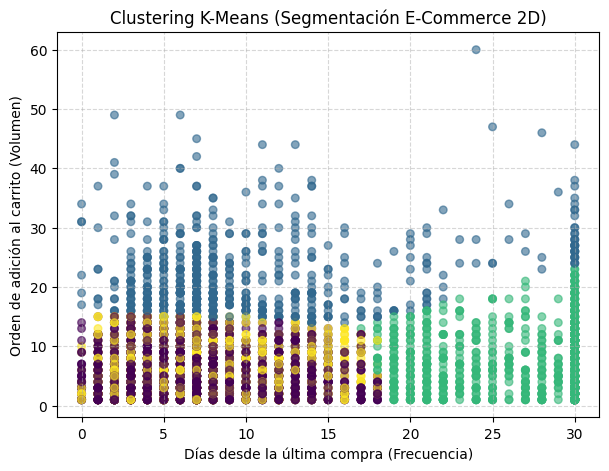

In [14]:
import os
import csv
import json
import time
import pandas as pd
import numpy as np
import kagglehub
import paho.mqtt.client as mqtt
from datetime import datetime
from dataclasses import dataclass, asdict
from typing import Literal
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# ==========================================
# 2. CARGA Y FILTRADO DE COLUMNAS
# ==========================================
print("⏳ Descargando dataset de E-commerce...")
path = kagglehub.dataset_download("hunter0007/ecommerce-dataset-for-predictive-marketing-2023")

csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
csv_file = os.path.join(path, csv_files[0])
df = pd.read_csv(csv_file)

print(f"📊 Dataset cargado con {len(df)} registros.")

# ==========================================
# 3. PIPELINE MIXTO EQUILIBRADO (MÉTRICAS + DEPTOS)
# ==========================================
# Variables numéricas cuantitativas
num_cols = ['days_since_prior_order', 'add_to_cart_order']
# Variables categóricas estructurales de negocio
cat_cols = ['department', 'reordered']

# Filtrado defensivo de seguridad
num_cols = [c for c in num_cols if c in df.columns]
cat_cols = [c for c in cat_cols if c in df.columns]

preprocessor = ColumnTransformer(
    transformers=[
        # Carril Numérico: Métricas de volumen y frecuencia
        ('num', Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('std', StandardScaler())
        ]), num_cols),
        
        # Carril Categórico: Estructura del inventario (One-Hot)
        ('cat', Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols)
    ]
)

print("🛠️ Ejecutando codificación macro-comercial...")
X_proc = preprocessor.fit_transform(df)

if hasattr(X_proc, "toarray"):
    X_proc = X_proc.toarray()
X_proc = np.asarray(X_proc).astype(np.float32)

columnas_finales = preprocessor.get_feature_names_out()
print(f"📐 Matriz final controlada. Dimensiones: {X_proc.shape}")
print(f"🚀 Buscando el codo óptimo sobre {len(columnas_finales)} variables sintéticas.")

# ==========================================
# 4. BUCLE DE K VARIABLE (MÉTODO DEL CODO)
# ==========================================
monitor = KMeansMetricsMonitor("Ecommerce_Departments_Elbow_Demo")
start_time = time.time()

print("🚀 Generando curva del codo en base a macro-categorías...")

for k in range(1, 11):
    model = KMeans(
        n_clusters=k,        
        init='k-means++', 
        n_init=15,           # Subimos reinicios para una curva sumamente suave y perfecta
        max_iter=300, 
        random_state=42,
        algorithm='lloyd'
    )
    model.fit(X_proc)
    
    # Enviamos K e Inercia directamente a tu GUI por MQTT
    monitor.send_metrics(k, model.inertia_)
    
    print(f"📦 Evaluando K = {k} | Inercia por Departamento: {model.inertia_:.2f}")
    time.sleep(0.4)

print(f"✅ Curva del codo calculada con éxito en {time.time() - start_time:.2f} segundos.")


# ==========================================
# 5. VISUALIZACIÓN EN 2D DIRECTA (TU ENFOQUE)
# ==========================================
# 1. Entrenamos el modelo definitivo con tu K óptima (ej: 4 clústeres)
k_optimo = 4
model_final = KMeans(n_clusters=k_optimo, init='k-means++', n_init=15, random_state=42)
y_pred = model_final.fit_predict(X_proc) # Entrena y asigna el clúster a cada fila

# 2. Tomamos una muestra aleatoria de 5.000 filas para que Matplotlib no congele la GUI
sample_idx = np.random.choice(len(X_proc), min(5000, len(X_proc)), replace=False)

# 3. Tu código adaptado: Cruzamos las dos variables numéricas continuas reales
plt.figure(figsize=(7, 5))

# Usamos el slice del sample para graficar
plt.scatter(
    df.iloc[sample_idx]['days_since_prior_order'],  # Eje X: Frecuencia de compra
    df.iloc[sample_idx]['add_to_cart_order'],       # Eje Y: Volumen en carrito
    c=y_pred[sample_idx], 
    cmap='viridis', 
    s=30, 
    alpha=0.6
)

# 4. Añadimos las etiquetas de tus variables reales
plt.xlabel('Días desde la última compra (Frecuencia)')
plt.ylabel('Orden de adición al carrito (Volumen)')
plt.title("Clustering K-Means (Segmentación E-Commerce 2D)")
plt.grid(True, linestyle='--', alpha=0.5)

# Guardamos y mostramos
plt.savefig(f"{folder}/Scatter_Directo_2D.png", dpi=300, bbox_inches='tight')
plt.show()

In [11]:
import os
import csv
import json
import time
import pandas as pd
import numpy as np
import kagglehub
import paho.mqtt.client as mqtt
from datetime import datetime
from dataclasses import dataclass, asdict
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline


# ==========================================
# 2. CARGA Y PREPARACIÓN RFM
# ==========================================
print("⏳ Descargando Online Retail Dataset...")
path = kagglehub.dataset_download("hellbuoy/online-retail-customer-clustering")
csv_file = os.path.join(path, "OnlineRetail.csv")

# Cargamos con latin1 porque a veces estos CSVs tienen caracteres especiales
df = pd.read_csv(csv_file, encoding='latin1')

# --- LIMPIEZA RÁPIDA ---
df = df.dropna()
df['CustomerID'] = df['CustomerID'].astype(str)
df['Amount'] = df['Quantity'] * df['UnitPrice']

# --- CONSTRUCCIÓN DE ATRIBUTOS (RFM) ---
# Agrupamos por cliente para tener métricas reales de negocio
# 1. Monetary (Total gastado)
monetary = df.groupby('CustomerID')['Amount'].sum().reset_index()

# 2. Frequency (Número de facturas únicas)
frequency = df.groupby('CustomerID')['InvoiceNo'].count().reset_index()

# Combinamos
X = pd.merge(monetary, frequency, on='CustomerID', how='inner')
X = X[['Amount', 'InvoiceNo']] # Nos quedamos solo con los números para K-Means

print(f"✅ Perfiles de cliente listos: {len(X)} usuarios únicos.")

# ==========================================
# 3. PREPROCESAMIENTO
# ==========================================
pipeline = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('std', StandardScaler())
])

X_proc = pipeline.fit_transform(X)
X_proc = np.asarray(X_proc).astype(np.float32)

# ==========================================
# 4. ENTRENAMIENTO ITERATIVO
# ==========================================
monitor = KMeansMetricsMonitor("Retail_RFM_Segmentation")
start_time = time.time()

print("🚀 Segmentando clientes por valor y frecuencia...")

for i in range(1, 51):
    model = KMeans(
        n_clusters=i,        # 4 grupos: VIP, Recuentes, Ocasionales, Riesgo
        init='k-means++', 
        n_init=50,           # Forzamos CPU para la demo 
        random_state=42
    )
    model.fit(X_proc)
    
    monitor.send_metrics(i, model.inertia_)
    
    if i % 20 == 0:
        print(f"📦 Paso {i}/100 | Inercia: {model.inertia_:.2f}")

print(f"✅ Segmentación finalizada en {time.time()-start_time:.2f}s")

⏳ Descargando Online Retail Dataset...
✅ Perfiles de cliente listos: 4372 usuarios únicos.


C:\Users\samue\AppData\Local\Temp\ipykernel_22000\1955917909.py:5: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  self.mqtt_client = mqtt.Client()


❌ Error MQTT: timed out
🚀 Segmentando clientes por valor y frecuencia...
📦 Paso 20/100 | Inercia: 184.27
📦 Paso 40/100 | Inercia: 57.51
✅ Segmentación finalizada en 11.47s


⏳ Descargando dataset de Spotify...
📊 Dataset cargado con 900 canciones.
🛠️ Aplicando Pipeline balanceado (Números + Categorías)...
📐 Matriz final controlada. Dimensiones: (900, 12) (12 variables sintéticas)


C:\Users\samue\AppData\Local\Temp\ipykernel_9448\1955917909.py:5: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  self.mqtt_client = mqtt.Client()


❌ Error MQTT: timed out
🚀 Generando curva del codo equilibrada...
🎵 Evaluando K = 1 | Inercia: 4669.15
🎵 Evaluando K = 2 | Inercia: 3488.96
🎵 Evaluando K = 3 | Inercia: 2995.72
🎵 Evaluando K = 4 | Inercia: 2628.71
🎵 Evaluando K = 5 | Inercia: 2437.84
🎵 Evaluando K = 6 | Inercia: 2287.72
🎵 Evaluando K = 7 | Inercia: 2155.17
🎵 Evaluando K = 8 | Inercia: 2059.50
🎵 Evaluando K = 9 | Inercia: 1963.66
🎵 Evaluando K = 10 | Inercia: 1886.07
🎵 Evaluando K = 11 | Inercia: 1822.53
🎵 Evaluando K = 12 | Inercia: 1766.66
🎵 Evaluando K = 13 | Inercia: 1716.30
🎵 Evaluando K = 14 | Inercia: 1668.33
🎵 Evaluando K = 15 | Inercia: 1622.51
🎵 Evaluando K = 16 | Inercia: 1594.11
🎵 Evaluando K = 17 | Inercia: 1552.52
🎵 Evaluando K = 18 | Inercia: 1522.36
🎵 Evaluando K = 19 | Inercia: 1482.54
🎵 Evaluando K = 20 | Inercia: 1452.81
✅ Análisis de la Regla del Codo completado en 9.59 segundos.

🎨 Generando gráfico de dispersión emocional 2D...


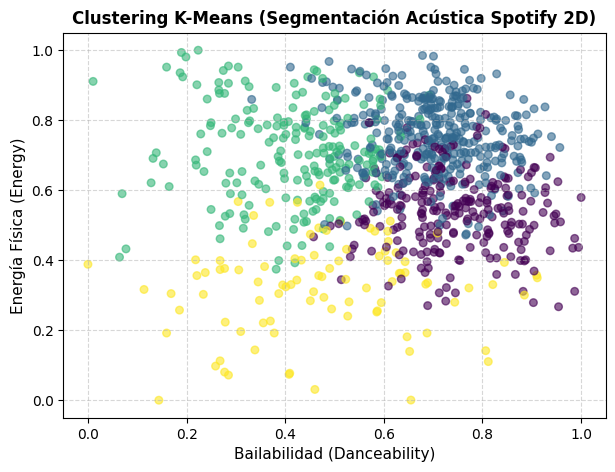

In [15]:
import os
import csv
import json
import time
import pandas as pd
import numpy as np
import kagglehub
import paho.mqtt.client as mqtt
from datetime import datetime
from dataclasses import dataclass, asdict
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ==========================================
# 1. CONFIGURACIÓN MQTT Y DTOS
# ==========================================

# ==========================================
# 2. CARGA DEL DATASET DE SPOTIFY
# ==========================================
print("⏳ Descargando dataset de Spotify...")
path = kagglehub.dataset_download("rishabhpancholi1302/spotify-most-popular-songs-dataset")

csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
csv_file = os.path.join(path, csv_files[0])
df = pd.read_csv(csv_file)

print(f"📊 Dataset cargado con {len(df)} canciones.")

# ==========================================
# 3. PIPELINE MIXTO EQUILIBRADO
# ==========================================
# Columnas numéricas clave
num_cols = ['danceability', 'energy', 'valence', 'loudness', 'popularity']
# Columnas categóricas fijas (Baja dimensionalidad)
cat_cols = ['playlist_genre', 'mode']

# Filtrado dinámico por seguridad
num_cols = [c for c in num_cols if c in df.columns]
cat_cols = [c for c in cat_cols if c in df.columns]

preprocessor = ColumnTransformer(
    transformers=[
        # Ondas de audio y éxito
        ('num', Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('std', StandardScaler())
        ]), num_cols),
        
        # Géneros musicales e interruptor armónico (One-Hot)
        ('cat', Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols)
    ]
)

print("🛠️ Aplicando Pipeline balanceado (Números + Categorías)...")
X_proc = preprocessor.fit_transform(df)

if hasattr(X_proc, "toarray"):
    X_proc = X_proc.toarray()
X_proc = np.asarray(X_proc).astype(np.float32)

columnas_finales = preprocessor.get_feature_names_out()
print(f"📐 Matriz final controlada. Dimensiones: {X_proc.shape} ({len(columnas_finales)} variables sintéticas)")

# ==========================================
# 4. BUCLE DE K VARIABLE (MÉTODO DEL CODO)
# ==========================================
monitor = KMeansMetricsMonitor("Spotify_Hybrid_Elbow_Demo")
start_time = time.time()

print("🚀 Generando curva del codo equilibrada...")

for k in range(1, 21):
    model = KMeans(
        n_clusters=k,        
        init='k-means++', 
        n_init=30,            
        random_state=42,
        algorithm='lloyd'
    )
    model.fit(X_proc)
    
    # Enviamos K e Inercia a la GUI
    monitor.send_metrics(k, model.inertia_)
    
    print(f"🎵 Evaluando K = {k} | Inercia: {model.inertia_:.2f}")
    time.sleep(0.4)

print(f"✅ Análisis de la Regla del Codo completado en {time.time() - start_time:.2f} segundos.")


import matplotlib.pyplot as plt

# ==========================================
# 5. VISUALIZACIÓN EN 2D DIRECTA (SPOTIFY)
# ==========================================
print("\n🎨 Generando gráfico de dispersión emocional 2D...")

# 1. Entrenamos el modelo definitivo con el K óptimo elegido (ej: 4 clústeres)
k_optimo = 4
model_final = KMeans(n_clusters=k_optimo, init='k-means++', n_init=15, random_state=42)
y_pred = model_final.fit_predict(X_proc) # Entrena y asigna el clúster (0, 1, 2...)

# 2. Tomamos una muestra aleatoria de 5.000 canciones para evitar saturar los recursos de la GUI
sample_idx = np.random.choice(len(X_proc), min(5000, len(X_proc)), replace=False)

# 3. Tu estructura de código: Cruzamos dos variables físicas reales
plt.figure(figsize=(7, 5))

plt.scatter(
    df.iloc[sample_idx]['danceability'],  # Eje X: Capacidad de baile (0 a 1)
    df.iloc[sample_idx]['energy'],        # Eje Y: Intensidad/Energía (0 a 1)
    c=y_pred[sample_idx], 
    cmap='viridis', 
    s=30, 
    alpha=0.6
)

# 4. Configuración estética y descriptiva para la defensa
plt.xlabel('Bailabilidad (Danceability)', fontsize=11)
plt.ylabel('Energía Física (Energy)', fontsize=11)
plt.title("Clustering K-Means (Segmentación Acústica Spotify 2D)", fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)

# Guardamos el archivo y desplegamos la ventana gráfica
plt.savefig(f"{folder}/Spotify_Scatter_Directo_2D.png", dpi=300, bbox_inches='tight')
plt.show()